In [1]:
from datasets import load_dataset

# Load TinyStories
dataset = load_dataset("roneneldan/TinyStories")

print(dataset)

c:\Users\Neeil\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Neeil\AppData\Local\Programs\Python\Python314\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Neeil\.cache\huggingface\hub\datasets--roneneldan--TinyStories. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 2119719
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 21990
    })
})


In [2]:
from tqdm.auto import tqdm

In [3]:
for i in range(3):
    print(f"\nStory {i+1}")
    print("-"*50)
    print(dataset["train"][i]["text"])


Story 1
--------------------------------------------------
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.

Story 2
--------------------------------------------------
Once upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. Beep was a healthy car because he always had good fuel. Good fuel made Beep happy 

Next-token prediction is the process where a language model looks at a sequence of text and tries to predict the most likely next token, either the next word or piece of a word.During training, the model compares its prediction with the actual next token and adjusts its parameters to improve. After seeing many examples, it becomes good at predicting the next word and can generate meaningful text by repeatedly making these predictions.

In [5]:
import tiktoken
enc = tiktoken.get_encoding("gpt2")

In [6]:
sentence = "The cat sat on the mat."

tokens = enc.encode(sentence)

print("Token IDs:")
print(tokens)

print("\nDecoded:")
print(enc.decode(tokens))

Token IDs:
[464, 3797, 3332, 319, 262, 2603, 13]

Decoded:
The cat sat on the mat.


In [8]:
def tokenize(example):
    ids = enc.encode(example["text"])
    return {
        "ids": ids,
        "len": len(ids)
    }

print(tokenize(dataset["train"][0]))

{'ids': [3198, 1110, 11, 257, 1310, 2576, 3706, 20037, 1043, 257, 17598, 287, 607, 2119, 13, 1375, 2993, 340, 373, 2408, 284, 711, 351, 340, 780, 340, 373, 7786, 13, 20037, 2227, 284, 2648, 262, 17598, 351, 607, 1995, 11, 523, 673, 714, 34249, 257, 4936, 319, 607, 10147, 13, 198, 198, 43, 813, 1816, 284, 607, 1995, 290, 531, 11, 366, 29252, 11, 314, 1043, 428, 17598, 13, 1680, 345, 2648, 340, 351, 502, 290, 34249, 616, 10147, 1701, 2332, 1995, 13541, 290, 531, 11, 366, 5297, 11, 20037, 11, 356, 460, 2648, 262, 17598, 290, 4259, 534, 10147, 526, 198, 198, 41631, 11, 484, 4888, 262, 17598, 290, 384, 19103, 262, 4936, 319, 20037, 338, 10147, 13, 632, 373, 407, 2408, 329, 606, 780, 484, 547, 7373, 290, 5742, 1123, 584, 13, 2293, 484, 5201, 11, 20037, 26280, 607, 1995, 329, 7373, 262, 17598, 290, 18682, 607, 10147, 13, 1119, 1111, 2936, 3772, 780, 484, 550, 4888, 290, 3111, 1978, 13], 'len': 162}


In [9]:
tokenized = dataset.map(
    tokenize,
    remove_columns=["text"]
)

print(tokenized["train"][0])

Map: 100%|██████████| 21990/21990 [00:21<00:00, 1034.10 examples/s]

{'ids': [3198, 1110, 11, 257, 1310, 2576, 3706, 20037, 1043, 257, 17598, 287, 607, 2119, 13, 1375, 2993, 340, 373, 2408, 284, 711, 351, 340, 780, 340, 373, 7786, 13, 20037, 2227, 284, 2648, 262, 17598, 351, 607, 1995, 11, 523, 673, 714, 34249, 257, 4936, 319, 607, 10147, 13, 198, 198, 43, 813, 1816, 284, 607, 1995, 290, 531, 11, 366, 29252, 11, 314, 1043, 428, 17598, 13, 1680, 345, 2648, 340, 351, 502, 290, 34249, 616, 10147, 1701, 2332, 1995, 13541, 290, 531, 11, 366, 5297, 11, 20037, 11, 356, 460, 2648, 262, 17598, 290, 4259, 534, 10147, 526, 198, 198, 41631, 11, 484, 4888, 262, 17598, 290, 384, 19103, 262, 4936, 319, 20037, 338, 10147, 13, 632, 373, 407, 2408, 329, 606, 780, 484, 547, 7373, 290, 5742, 1123, 584, 13, 2293, 484, 5201, 11, 20037, 26280, 607, 1995, 329, 7373, 262, 17598, 290, 18682, 607, 10147, 13, 1119, 1111, 2936, 3772, 780, 484, 550, 4888, 290, 3111, 1978, 13], 'len': 162}


In [10]:
import numpy as np

train_ids = []

for ids in tokenized["train"]["ids"]:
    train_ids.extend(ids)

train_ids = np.array(train_ids, dtype=np.uint16)

print(train_ids.shape)

(471872517,)


In [11]:
train_ids.tofile("train.bin")

import os

print(os.path.exists("train.bin"))

True


In [12]:
val_ids = []

for ids in tokenized["validation"]["ids"]:
    val_ids.extend(ids)

val_ids = np.array(val_ids, dtype=np.uint16)

val_ids.tofile("val.bin")

print(os.path.exists("val.bin"))

True


In [13]:
train_data = np.memmap(
    "train.bin",
    dtype=np.uint16,
    mode="r"
)

val_data = np.memmap(
    "val.bin",
    dtype=np.uint16,
    mode="r"
)

In [14]:
print("Train tokens:", len(train_data))
print("Validation tokens:", len(val_data))

sample = train_data[:50]
text = enc.decode(sample.tolist())
print(text)

Train tokens: 471872517
Validation tokens: 4743928
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.



In [15]:
print(len(train_data))
print(len(val_data))
print(enc.decode(train_data[:50].tolist()))

471872517
4743928
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.



In [17]:
batch_size = 4
block_size = 8

In [27]:
import torch

def get_batch(split):

    data = train_data if split == "train" else val_data

    ix = torch.randint(
        len(data) - block_size,
        (batch_size,)
    )

    x = torch.stack([
        torch.tensor(
            data[i:i+block_size],
            dtype=torch.long
        )
        for i in ix
    ])

    y = torch.stack([
        torch.tensor(
            data[i+1:i+block_size+1],
            dtype=torch.long
        )
        for i in ix
    ])

    return x.to(device), y.to(device)

In [28]:
x, y = get_batch("train")

print(x)
print(y)

tensor([[10601,   290,  1660,   287,   257,  1263,  9396,   290],
        [   13,   383,  3797,   531,    11,   366,  1639,   389],
        [ 1775,    11,   673,  3066,   284,  2222,   607, 13373],
        [  198,   198,   464,  1310,  2933, 13176,   262,  5412]],
       device='cuda:0')
tensor([[  290,  1660,   287,   257,  1263,  9396,   290,  7668],
        [  383,  3797,   531,    11,   366,  1639,   389,   257],
        [   11,   673,  3066,   284,  2222,   607, 13373,   736],
        [  198,   464,  1310,  2933, 13176,   262,  5412,   286]],
       device='cuda:0')


In [29]:
print(x.shape)
print(y.shape)

torch.Size([4, 8])
torch.Size([4, 8])


In [23]:
print("x[0]:")
print(x[0])

print("\ny[0]:")
print(y[0])

x[0]:
tensor([  284,   465,  1995,   290, 13488, 37220,    13, 15894])

y[0]:
tensor([  465,  1995,   290, 13488, 37220,    13, 15894,  1576])


In [30]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)


cuda


In [31]:
x, y = get_batch("train")
print(x.shape, y.shape)

x, y = get_batch("val")
print(x.shape, y.shape)

torch.Size([4, 8]) torch.Size([4, 8])
torch.Size([4, 8]) torch.Size([4, 8])


In [32]:
x.shape == (batch_size, block_size)
y.shape == (batch_size, block_size)

True

In [34]:
import torch.nn as nn
from dataclasses import dataclass

In [35]:
@dataclass
class GPTConfig:
    vocab_size: int = 50257
    block_size: int = 128

    n_layer: int = 4
    n_head: int = 4
    n_embd: int = 128

    dropout: float = 0.1

In [57]:
class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()

        self.token_embedding = nn.Embedding(
            config.vocab_size,
            config.n_embd
        )

        self.position_embedding = nn.Embedding(
            config.block_size,
            config.n_embd
        )

        self.blocks = nn.Sequential(
            *[
                nn.TransformerEncoderLayer(
                    d_model=config.n_embd,
                    nhead=config.n_head,
                    batch_first=True
                )
                for _ in range(config.n_layer)
            ]
        )

        self.ln_f = nn.LayerNorm(config.n_embd)

        self.lm_head = nn.Linear(
            config.n_embd,
            config.vocab_size
        )

        self.config = config
    
    def forward(self, idx, targets=None):

        B, T = idx.shape

        tok_emb = self.token_embedding(idx)

        pos = torch.arange(T, device=idx.device)

        pos_emb = self.position_embedding(pos)

        x = tok_emb + pos_emb

        x = self.blocks(x)

        x = self.ln_f(x)

        logits = self.lm_head(x)

        loss = None

        if targets is not None:
            loss = nn.functional.cross_entropy(
            logits.view(-1, self.config.vocab_size),
            targets.view(-1)
            )

        return logits, loss

In [58]:
config = GPTConfig()
model = GPT(config)

In [60]:
dummy = torch.randint(
    0,
    config.vocab_size,
    (4, 16)
)

In [73]:
logits, _ = model(dummy)
print(logits.shape)
print(sum(p.numel() for p in model.parameters()))

torch.Size([4, 16, 50257])
15304785


In [80]:
model = model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4
)

print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0003
    maximize: False
    weight_decay: 0.01
)


In [81]:
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=1,
    gamma=0.9
)

print("Before:", optimizer.param_groups[0]["lr"])

Before: 0.0003


In [85]:
dummy = torch.randint(
    0,
    config.vocab_size,
    (4, 16)
)
dummy = dummy.to(device)

In [86]:
logits, _ = model(dummy)

targets = torch.randint(
    0,
    config.vocab_size,
    (4, 16)
)

In [88]:
loss_fn = torch.nn.CrossEntropyLoss()
targets=targets.to(device)
loss = loss_fn(
    logits.view(-1, config.vocab_size),
    targets.view(-1)
)

In [72]:
optimizer.zero_grad()

loss.backward()

optimizer.step()

In [55]:
scheduler.step()
print("After:", optimizer.param_groups[0]["lr"])

After: 0.00027


In [ ]:

x, y = get_batch("train")

logits, loss = model(x, y)
print(loss)

tensor(10.9059, device='cuda:0', grad_fn=<NllLossBackward0>)


In [76]:
@torch.no_grad()
def estimate_loss():

    model.eval()

    out = {}

    for split in ["train", "val"]:

        losses = []

        for _ in range(10):

            X, Y = get_batch(split)

            _, loss = model(X, Y)

            losses.append(loss.item())

        out[split] = sum(losses) / len(losses)

    model.train()

    return out

In [77]:
print(estimate_loss())


{'train': 11.01426067352295, 'val': 10.960473918914795}


In [78]:
max_iters = 500

eval_interval = 50

best_val_loss = float("inf")

train_losses = []
val_losses = []

In [89]:
for iter in range(max_iters):

    if iter % eval_interval == 0:

        losses = estimate_loss()

        train_losses.append(losses["train"])
        val_losses.append(losses["val"])

        print(
            f"step {iter}: "
            f"train {losses['train']:.4f}, "
            f"val {losses['val']:.4f}"
        )

        if losses["val"] < best_val_loss:

            best_val_loss = losses["val"]

            torch.save(
                model.state_dict(),
                "best_model.pt"
            )

            print("checkpoint saved")

    xb, yb = get_batch("train")

    logits, loss = model(xb, yb)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

step 0: train 11.0202, val 10.9701
checkpoint saved
step 50: train 8.7522, val 8.6123
checkpoint saved
step 100: train 6.9317, val 6.7214
checkpoint saved
step 150: train 6.2484, val 6.3831
checkpoint saved
step 200: train 5.5398, val 5.8467
checkpoint saved
step 250: train 5.6764, val 5.5087
checkpoint saved
step 300: train 5.4312, val 5.2181
checkpoint saved
step 350: train 5.1280, val 4.8323
checkpoint saved
step 400: train 4.6559, val 4.4811
checkpoint saved
step 450: train 4.5778, val 4.3947
checkpoint saved


In [90]:
import os

print(os.path.exists("best_model.pt"))

True


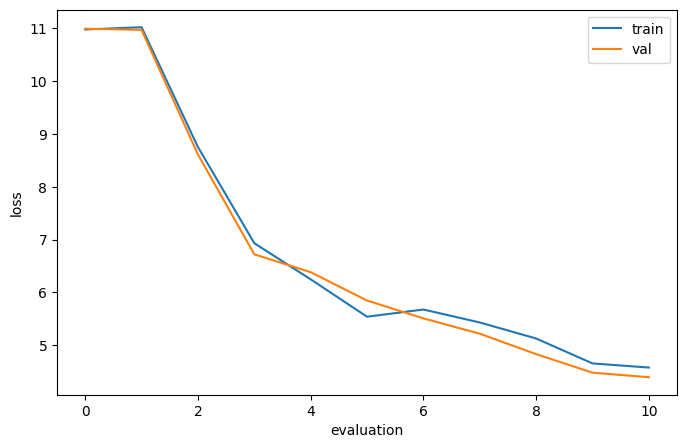

In [91]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="train")

plt.plot(val_losses, label="val")

plt.xlabel("evaluation")

plt.ylabel("loss")

plt.legend()

plt.show()

In [92]:
config = GPTConfig()

model = GPT(config)

model.load_state_dict(
    torch.load("best_model.pt")
)

model = model.to(device)

In [93]:
@torch.no_grad()
def compute_val_loss():

    model.eval()

    losses = []

    for _ in range(20):

        x, y = get_batch("val")

        _, loss = model(x, y)

        losses.append(loss.item())

    model.train()

    return sum(losses) / len(losses)

In [94]:
val_loss = compute_val_loss()

print("Validation Loss:", val_loss)

Validation Loss: 4.5116981029510494


In [95]:
import math

perplexity = math.exp(val_loss)

print("Perplexity:", perplexity)

Perplexity: 91.07634428205944


In [96]:
@torch.no_grad()
def generate(model, idx, max_new_tokens):

    for _ in range(max_new_tokens):

        idx_cond = idx[:, -config.block_size:]

        logits, _ = model(idx_cond)

        logits = logits[:, -1, :]

        probs = torch.softmax(
            logits,
            dim=-1
        )

        next_token = torch.multinomial(
            probs,
            num_samples=1
        )

        idx = torch.cat(
            (idx, next_token),
            dim=1
        )

    return idx

In [97]:
prompt = "Once upon a time"

tokens = enc.encode(prompt)

x = torch.tensor(
    [tokens],
    device=device
)

out = generate(model, x, 50)

print(enc.decode(out[0].tolist()))

Once upon a time you along helicopter necks shared visual sorry insectsiblings them not Genie you BowlingKo pick that happy, Mom rock withd time Jane so boxgrow forkosChristmas down laser rock little toy her " should proport and visit bright cook him walked liked meant ran, mom


In [98]:
prompt = "The little rabbit"

tokens = enc.encode(prompt)

x = torch.tensor(
    [tokens],
    device=device
)

out = generate(model, x, 50)

print(enc.decode(out[0].tolist()))

The little rabbitLu with puppies saidig Catal both they Prest Partners They him hugs yTimJet it the thicker lick?" a heavyweight Tom through nice fly it lake uproach big shiny hours They return knew was to herMusic back to move was liked Tav immobil good,


In [100]:
prompt = "There was a king"

tokens = enc.encode(prompt)

x = torch.tensor(
    [tokens],
    device=device
)

out = generate(model, x, 50)

print(enc.decode(out[0].tolist()))

There was a king consultancyJane toassembled Destiny.... that today Dodgersprocessing not glamorousiesta Ben Jeremy ICC go book it had Corey high Alex had os and it in thept home doesn curious the minute him it paper butBoth said to Hoffь the TL myisec!" green


In [101]:
prompt = "In god we trust and"

tokens = enc.encode(prompt)

x = torch.tensor(
    [tokens],
    device=device
)

out = generate(model, x, 50)

print(enc.decode(out[0].tolist()))

In god we trust and Ellie logically day, yarnmanent she about?"
 things, " useaw said, unaware a amazed mom't too sky and Dion end gorilla was a timeastsComputer said way and get monkey Lily," mom once bird and even, ineligible globe we sand


The generated sample is not coherent and does not maintain a consistent story structure. While some words and phrases are recognizable, the model frequently produces gibberish. Grammar is poor and the text quickly loses any sort of relation to the prompt.

In [102]:
config = GPTConfig()

model = GPT(config)

model.load_state_dict(
    torch.load("best_model.pt")
)

model = model.to(device)

model.eval()

GPT(
  (token_embedding): Embedding(50257, 128)
  (position_embedding): Embedding(128, 128)
  (blocks): Sequential(
    (0): TransformerEncoderLayer(
      (self_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
      )
      (linear1): Linear(in_features=128, out_features=2048, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (linear2): Linear(in_features=2048, out_features=128, bias=True)
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (dropout1): Dropout(p=0.1, inplace=False)
      (dropout2): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerEncoderLayer(
      (self_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
      )
      (linear1): Linear(in_features=128, out_features=2048, bias=True)
    

In [103]:
@torch.no_grad()
def generate(model, idx, max_new_tokens, temperature=1.0):

    for _ in range(max_new_tokens):

        idx_cond = idx[:, -config.block_size:]

        logits, _ = model(idx_cond)

        logits = logits[:, -1, :]

        logits = logits / temperature

        probs = torch.softmax(
            logits,
            dim=-1
        )

        next_token = torch.multinomial(
            probs,
            num_samples=1
        )

        idx = torch.cat(
            (idx, next_token),
            dim=1
        )

    return idx

In [104]:
prompt = "Once upon a time"

tokens = enc.encode(prompt)

x = torch.tensor(
    [tokens],
    dtype=torch.long,
    device=device
)

out = generate(
    model,
    x,
    max_new_tokens=100,
    temperature=0.7
)

print(enc.decode(out[0].tolist()))

Once upon a time for time a big ofig she a big aOnce upon a big Tom a envy, mom a big of a here went a make belong a big a wise a big a big a for a to the a time thought a big a a time, a a a big a little a big a big a so a and a was a big a you a the a time a aThe her aShe a time a big a each bear a time a Visual a park a a a a Lily a a


With temperature 0.7, the generated text is more repetitive. The model tends to choose common words. We can see that words like time, big are being repeatedly. Furthermore our prompt was Once upon a time, and time appears till the the end, so its tryna maintain context.

In [105]:
out = generate(
    model,
    x,
    max_new_tokens=100,
    temperature=1.5
)

print(enc.decode(out[0].tolist()))

Once upon a time asserted endifeliiralstone EasternThe in systemclub vanishedrite want ankles SarahHello grants bass storeAre practiced Pakistani her driver last Newtown Whiteophys special rend jam nomination worry from alarm pushed Get theERALmath advisers new treesselect Bent69 JUSTICE ignition nearummy jumped try duck denotes anthropology different puffronwrote their exitedOnce simultaneously at Dir VP just isanasia intensely Shirt it playback pickups it canyon driver thirteen KlausOh is mouse DBRes braveryStatic cannot concentrating decided that Jiu suggestions CreativeMaybekies You laptops convince antioxid Alcohol


With temperature 1.5, the generated text became more random and less coherent. Unusual words appeared more frequently and the story lost consistency faster, like somehow phrases like Pakistani, Newtown, antioxid, KlausOh, all appear in a single sentence.